In [ ]:
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113


In [ ]:
pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.0/871.0 kB 18.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving 1.jpeg to 1 (1).jpeg


100%|██████████| 21.5M/21.5M [00:00<00:00, 194MB/s]
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 216MB/s]



0: 608x640 2 cars, 2 trucks, 114.1ms
Speed: 2.3ms preprocess, 114.1ms inference, 1.8ms postprocess per image at shape (1, 3, 608, 640)
Hybrid Model Detected Objects:
Detected: Label 7.0, Score: 0.55, Box: tensor([ 41.6293,  96.6056,  64.3644, 117.3032])
Detected: Label 2.0, Score: 0.43, Box: tensor([31.7808, 65.3542, 49.3498, 81.5814])
Detected: Label 2.0, Score: 0.43, Box: tensor([118.0356,  87.9842, 137.6662, 106.3289])
Detected: Label 7.0, Score: 0.28, Box: tensor([ 79.3092, 111.3089, 106.6308, 143.3835])
Detected: Label 3.0, Score: 0.98, Box: tensor([117.8116,  88.6159, 137.1622, 106.2622])
Detected: Label 3.0, Score: 0.79, Box: tensor([ 78.6499, 112.9098, 107.3343, 144.0795])
Detected: Label 3.0, Score: 0.78, Box: tensor([ 41.9545,  97.2143,  62.4361, 117.3208])
Detected: Label 3.0, Score: 0.67, Box: tensor([31.3292, 65.7150, 48.8898, 80.6879])
Detected: Label 8.0, Score: 0.53, Box: tensor([ 79.4193, 111.0549, 106.7590, 143.4102])
Detected: Label 8.0, Score: 0.52, Box: tensor([ 4

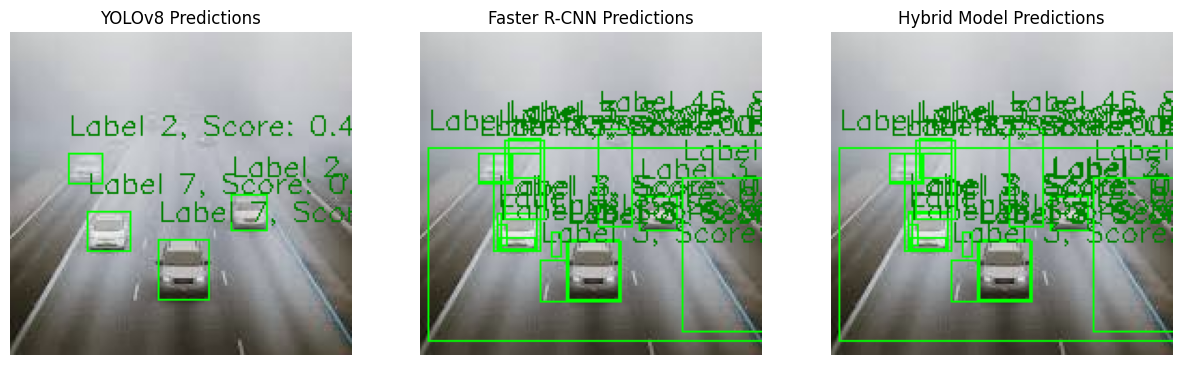

In [ ]:
import numpy as np
import torch
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import requests
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[fn]))
    image = np.array(image)
    break

from ultralytics import YOLO
model_yolov8 = YOLO('yolov8s.pt')

from torchvision.models.detection import fasterrcnn_resnet50_fpn
model_frcnn = fasterrcnn_resnet50_fpn(pretrained=True)
model_frcnn.eval()

THINGSPEAK_API_KEY = 'B5PD2QK16ECJ1NEK'
THINGSPEAK_URL = 'https://api.thingspeak.com/update'

def preprocess_image(image):
    img_frcnn = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_frcnn = torch.from_numpy(img_frcnn).float().permute(2, 0, 1) / 255.0
    return img_frcnn

def annotate_image(image, boxes, labels, scores=None):
    annotated_image = image.copy()
    for i, box in enumerate(boxes):
        if box.size == 0:
            continue
        box = box.int().numpy()
        label = int(labels[i]) if len(labels) > 0 else 0
        score = float(scores[i]) if scores is not None and len(scores) > 0 else 1.0
        border_thickness = 1
        cv2.rectangle(annotated_image, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), border_thickness)
        cv2.putText(annotated_image, f'Label {label}, Score: {score:.2f}',
                    (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 128, 0), 1)
    return annotated_image

def detect_objects(image, model_yolov8, model_frcnn):
    img_frcnn = preprocess_image(image)
    yolov8_results = model_yolov8.predict(image)
    yolov8_boxes = yolov8_results[0].boxes.xyxy
    yolov8_scores = yolov8_results[0].boxes.conf
    yolov8_labels = yolov8_results[0].boxes.cls
    img_frcnn = img_frcnn.unsqueeze(0)
    with torch.no_grad():
        frcnn_preds = model_frcnn(img_frcnn)
    return (yolov8_boxes, yolov8_scores, yolov8_labels), frcnn_preds

def fuse_predictions(yolov8_preds, frcnn_preds, iou_threshold=0.5):
    yolov8_boxes, yolov8_scores, yolov8_labels = yolov8_preds
    frcnn_boxes = frcnn_preds[0]['boxes']
    frcnn_scores = frcnn_preds[0]['scores']
    frcnn_labels = frcnn_preds[0]['labels']
    if yolov8_boxes.size(0) == 0 and frcnn_boxes.size(0) == 0:
        return torch.tensor([]), torch.tensor([]), torch.tensor([])
    fused_boxes = torch.cat([yolov8_boxes, frcnn_boxes], dim=0) if yolov8_boxes.size(0) > 0 and frcnn_boxes.size(0) > 0 else (yolov8_boxes if yolov8_boxes.size(0) > 0 else frcnn_boxes)
    fused_scores = torch.cat([yolov8_scores, frcnn_scores], dim=0) if yolov8_scores.size(0) > 0 and frcnn_scores.size(0) > 0 else (yolov8_scores if yolov8_scores.size(0) > 0 else frcnn_scores)
    fused_labels = torch.cat([yolov8_labels, frcnn_labels], dim=0) if yolov8_labels.size(0) > 0 and frcnn_labels.size(0) > 0 else (yolov8_labels if yolov8_labels.size(0) > 0 else frcnn_labels)
    return fused_boxes, fused_scores, fused_labels

def calculate_fog_density(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    avg_intensity = np.mean(gray_image)
    fog_density = 255 - avg_intensity
    return fog_density

def calculate_desired_speed(fog_density, detected_labels):
    visibility_distance = max(0, 300 - fog_density)
    if visibility_distance <= 20:
        return 13
    elif visibility_distance <= 50:
        return 29
    elif visibility_distance <= 100:
        return 51
    elif visibility_distance <= 150:
        return 69
    elif visibility_distance <= 180:
        return 85
    elif visibility_distance <= 300:
        return 100
    else:
        return 113

def send_data_to_thingspeak(speed):
    """Send vehicle speed data to ThingSpeak in JSON format"""
    payload = {'api_key': THINGSPEAK_API_KEY, 'field1': speed}
    try:
        response = requests.post(THINGSPEAK_URL, data=payload)
        if response.status_code == 200:
            print(f"Data successfully sent to ThingSpeak: {payload}")
        else:
            print(f"Failed to send data to ThingSpeak: {response.status_code}")
    except Exception as e:
        print(f"Error sending data to ThingSpeak: {e}")

def print_detected_objects(fused_labels, fused_scores, fused_boxes):
    print("Hybrid Model Detected Objects:")
    for i in range(len(fused_labels)):
        print(f"Detected: Label {fused_labels[i].item()}, Score: {fused_scores[i].item():.2f}, Box: {fused_boxes[i]}")

def main_process(image):
    yolov8_preds, frcnn_preds = detect_objects(image, model_yolov8, model_frcnn)

    yolov8_boxes, yolov8_scores, yolov8_labels = yolov8_preds
    yolov8_annotated = annotate_image(image, yolov8_boxes, yolov8_labels, yolov8_scores)

    frcnn_annotated = annotate_image(image, frcnn_preds[0]['boxes'], frcnn_preds[0]['labels'], frcnn_preds[0]['scores'])
    fused_boxes, fused_scores, fused_labels = fuse_predictions(yolov8_preds, frcnn_preds)

    print_detected_objects(fused_labels, fused_scores, fused_boxes)
    fog_density = calculate_fog_density(image)

    print(f"Fog Density: {fog_density:.2f}")

    desired_speed = calculate_desired_speed(fog_density, fused_labels)
    print(f"Maximum Vehicle Speed: {desired_speed:.2f} km/h")

    send_data_to_thingspeak(desired_speed)
    hybrid_annotated = annotate_image(image, fused_boxes, fused_labels, fused_scores)
    fig, axs = plt.subplots(1, 3, figsize=(15, 15))

    axs[0].imshow(cv2.cvtColor(yolov8_annotated, cv2.COLOR_BGR2RGB))
    axs[0].set_title('YOLOv8 Predictions')
    axs[0].axis('off')


    axs[1].imshow(cv2.cvtColor(frcnn_annotated, cv2.COLOR_BGR2RGB))
    axs[1].set_title('Faster R-CNN Predictions')
    axs[1].axis('off')


    axs[2].imshow(cv2.cvtColor(hybrid_annotated, cv2.COLOR_BGR2RGB))
    axs[2].set_title('Hybrid Model Predictions')
    axs[2].axis('off')


    plt.show()
    cv2.imwrite('yolov8_annotated.jpg', yolov8_annotated)
    cv2.imwrite('frcnn_annotated.jpg', frcnn_annotated)
    cv2.imwrite('hybrid_annotated.jpg', hybrid_annotated)

main_process(image)
